## <span style="color:blue"> Lezione 4 </span>


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as scipy
#import scienceplots



### <span style="color:DodgerBlue"> Esercizio 4.1  </span>


Si esegue una simulazione di dinamica molecolare per un sistema con 108 particelle soggette al potenziale di Lennard-Jones. Si utilizzano le unità ridotte, dipendenti dai parametri del sistema $\epsilon$ profondità della buca di potenziale, $\sigma$ posizione del minimo, $m$ massa delle particelle.


Si divide in $n_{\mathrm{bins}}=30$ l'intervallo $[0,v*_{\mathrm{max}}]$, dove si prende $v*_{\mathrm{max}}=4.0*T*$ , con $T^*$ temperatura del sistema all'inizializzazione. Questa scelta consente di mappare completamente l'intera distribuzione di velocità (gli ultimi bins, difatti, restano quasi sempre vuoti). Si costruisce quindi l'istogramma dei conteggi di $v*$ , con le loro incertezze ottenute tramite data blocking.

La simulazione viene eseguita con $N=10$ blocchi e $M=1000$ step per blocco. 



L'istogramma viene messo a confronto con la distribuzione di Maxwell-Boltzmann, in unità naturali:$$p(v^*,T^*) = \frac{1}{(2\pi T^*)^{3/2}} 4\pi (v^*)^2 e^{-\frac{(v^*)^2}{2 T^*}}$$

generata dal codice riportato sotto. 

In [12]:
def p(v,T):#distribuzione di Maxwell-Boltzmann
    return 1/pow(2*np.pi*T,3/2)*4*np.pi*v**2*np.exp(-v**2/(2*T))

I dati ottenuti con la simulazione sono caricati ed elaborati nella seguente cella: 

In [13]:
N=10 # numero blocchi
M=1000 # numero step 
n_BINS=30 #numero bins


data=pd.read_csv("l_04_es1/NSL_SIMULATOR/OUTPUT/pofv.dat",sep="\s+")
temp=pd.read_csv("l_04_es1/NSL_SIMULATOR/OUTPUT/temperature.dat",sep="\s+")

mask=data["#"]==N #seleziona l'ultimo blocco
values=data[mask] #seleziona i dati dell'ultimo blocco


T_sim=temp.at[N-1,"T_AVE:"] #salva la temperatura della simulazione, all'ultimo blocco



#prepara l'istogramma
bins=values["VELOCITY:"].to_numpy()
bin_size=bins[1]
bins+=bin_size/2 #centra i bins

counts=values["AVE_POFV:"]
error=values["ERROR:"]

#riscalamento (per confronto con Maxwell-Boltzmann)
norm = np.sum(counts) * bin_size
counts/=norm
error/=norm 



Nella cella sottostante è invece riportato il codice che grafica l'istogramma delle velocità ottenuto dalla simulazione, esegue il fit con la distribuzione di Maxwell-Boltzmann e compara in un'unica immagine istogramma, fit, e distribuzione attesa con T ricavata dalla simulazione.

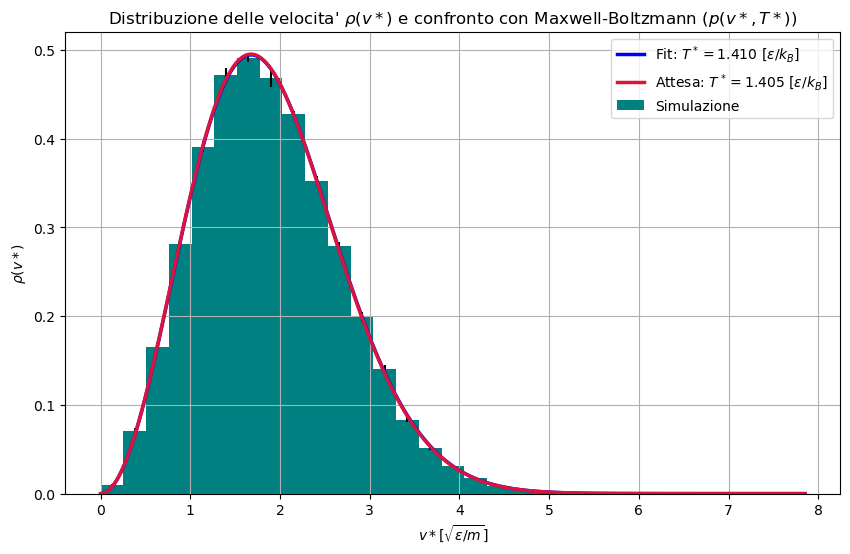

In [14]:
fig,ax=plt.subplots(1,1,figsize=[10,6]) 

#dati
ax.bar(bins,counts,width=bin_size,yerr=error,color="teal",label="Simulazione")
ax.grid(True)

#fit
T_fit=scipy.curve_fit(p,bins,counts)[0][0]
v=np.linspace(0,(len(bins)+1)*bin_size,1000)
plt.plot(v,p(v,T_fit),color="blue",linewidth=2.5,label=rf"Fit: $T^*=${T_fit:.3f} $[\epsilon/k_B] $")

#distribuzione attesa
plt.plot(v,p(v,T_sim),color="crimson",linewidth=2.5,label=rf"Attesa: $ T^*=${T_sim:.3f} $[\epsilon/k_B] $")


ax.set_xlabel(r"$v* [\sqrt{\epsilon/m}]$")
ax.set_ylabel(r"$\rho(v*)$")
ax.legend()
ax.set_title(rf"Distribuzione delle velocita' $\rho(v*)$ e confronto con Maxwell-Boltzmann ($p(v*,T*)$) ")

plt.show()

In nero sono indicate le barre di errore. Si nota che la temperatura in unità LJ ridotte ottenuta dal fit: $T^*=1.410 \  [\epsilon/k_B] $, è comparabile con la temperatura media del sistema calcolata durante la simulazione($T^*=1.405\  [\epsilon/k_B] $), ed è inferiore alla temperatura di inizializzazione del sistema (come atteso per conservazione dell'energia).

### <span style="color:DodgerBlue"> Esercizio 4.2  </span>


Il sistema è inizializzato in una condizione a bassa entropia: configurazione fcc con le particelle occupanti solo metà della box (ottenuto sostituendo _side con _halfside nell'inizializzazione del sistema), e con velocità pari a $v*_T = \sqrt{3T*}$ scelta con probabilità uniforme nelle sei direzioni possibili (x,y,z e avanti, indietro).Si osserva che, dopo un tempo sufficientemente lungo, la distribuzione delle velocità.

Per mostrare ciò si è fatta una simulazione con $N=400$ blocchi e $M=100$ step per blocco. La scelta del numero e grandezza dei bins è come per l'esercizio precedente. Sono poi stati scelti dieci di questi blocchi e per questi viene rappresentato l'istogramma delle velocità cumulativo ad essi, in aggiunta al fit con la distribuzione Maxwell-Boltzmann e al plot della distribuzione attesa con la temperatura ricavata dalla simulazione

In [15]:



N=20 # numero blocchi
M=2000 # numero step 
n_BINS=30 #numero bins

data=pd.read_csv("l_04_es2/NSL_SIMULATOR/OUTPUT/pofv.dat",sep="\s+")
temp=pd.read_csv("l_04_es2/NSL_SIMULATOR/OUTPUT/temperature.dat",sep="\s+")


bins=[]#salva gli estremi dei bins: comune a tutti i blocchi
bin_width=0#grandezza dei bin
show_block=[1,10,50,100,200,300,400] #sceglie i blocchi da mostrare
#show_block=[1,2,5,10,15,20]
block_counts={} #salva i conteggi, per ogni blocco scelto
block_error={}#salva l'errore, per ogni blocco scelto


T_fit=[]
T_sim=[]

for n in show_block:#per ogni blocco scelto
    mask=data["#"]==n 
    values=data[mask]
    if n==1: #i bins sono tutti ugali, salva i valori solo per il primo
        bins=values["VELOCITY:"].to_numpy()
        bin_width=bins[1]#poichè i bin partono da 0, la grandezza dei bin sarà pari al secondo numero nella sequenza
        bins+=bin_width/2#centra i bins

    #salva la temperatura della simulazione comulativa al blocco n
    T_sim.append(temp.at[n-1,"T_AVE:"])
    
    #prepara l'istogramma (cumulativo al blocco n),lo riscala e salva nel dizionario
 
    counts=values["AVE_POFV:"]
    error=values["ERROR:"]
    norm = np.sum(counts) * bin_width
    counts/=norm
    error/=norm 
    block_counts.update({n:counts })
    block_error.update({n:error })
    #poi esegue il fit alla  distribuzione di Maxwell-Boltzmann
    T_fit.append(scipy.curve_fit(p,bins,block_counts[n])[0][0])




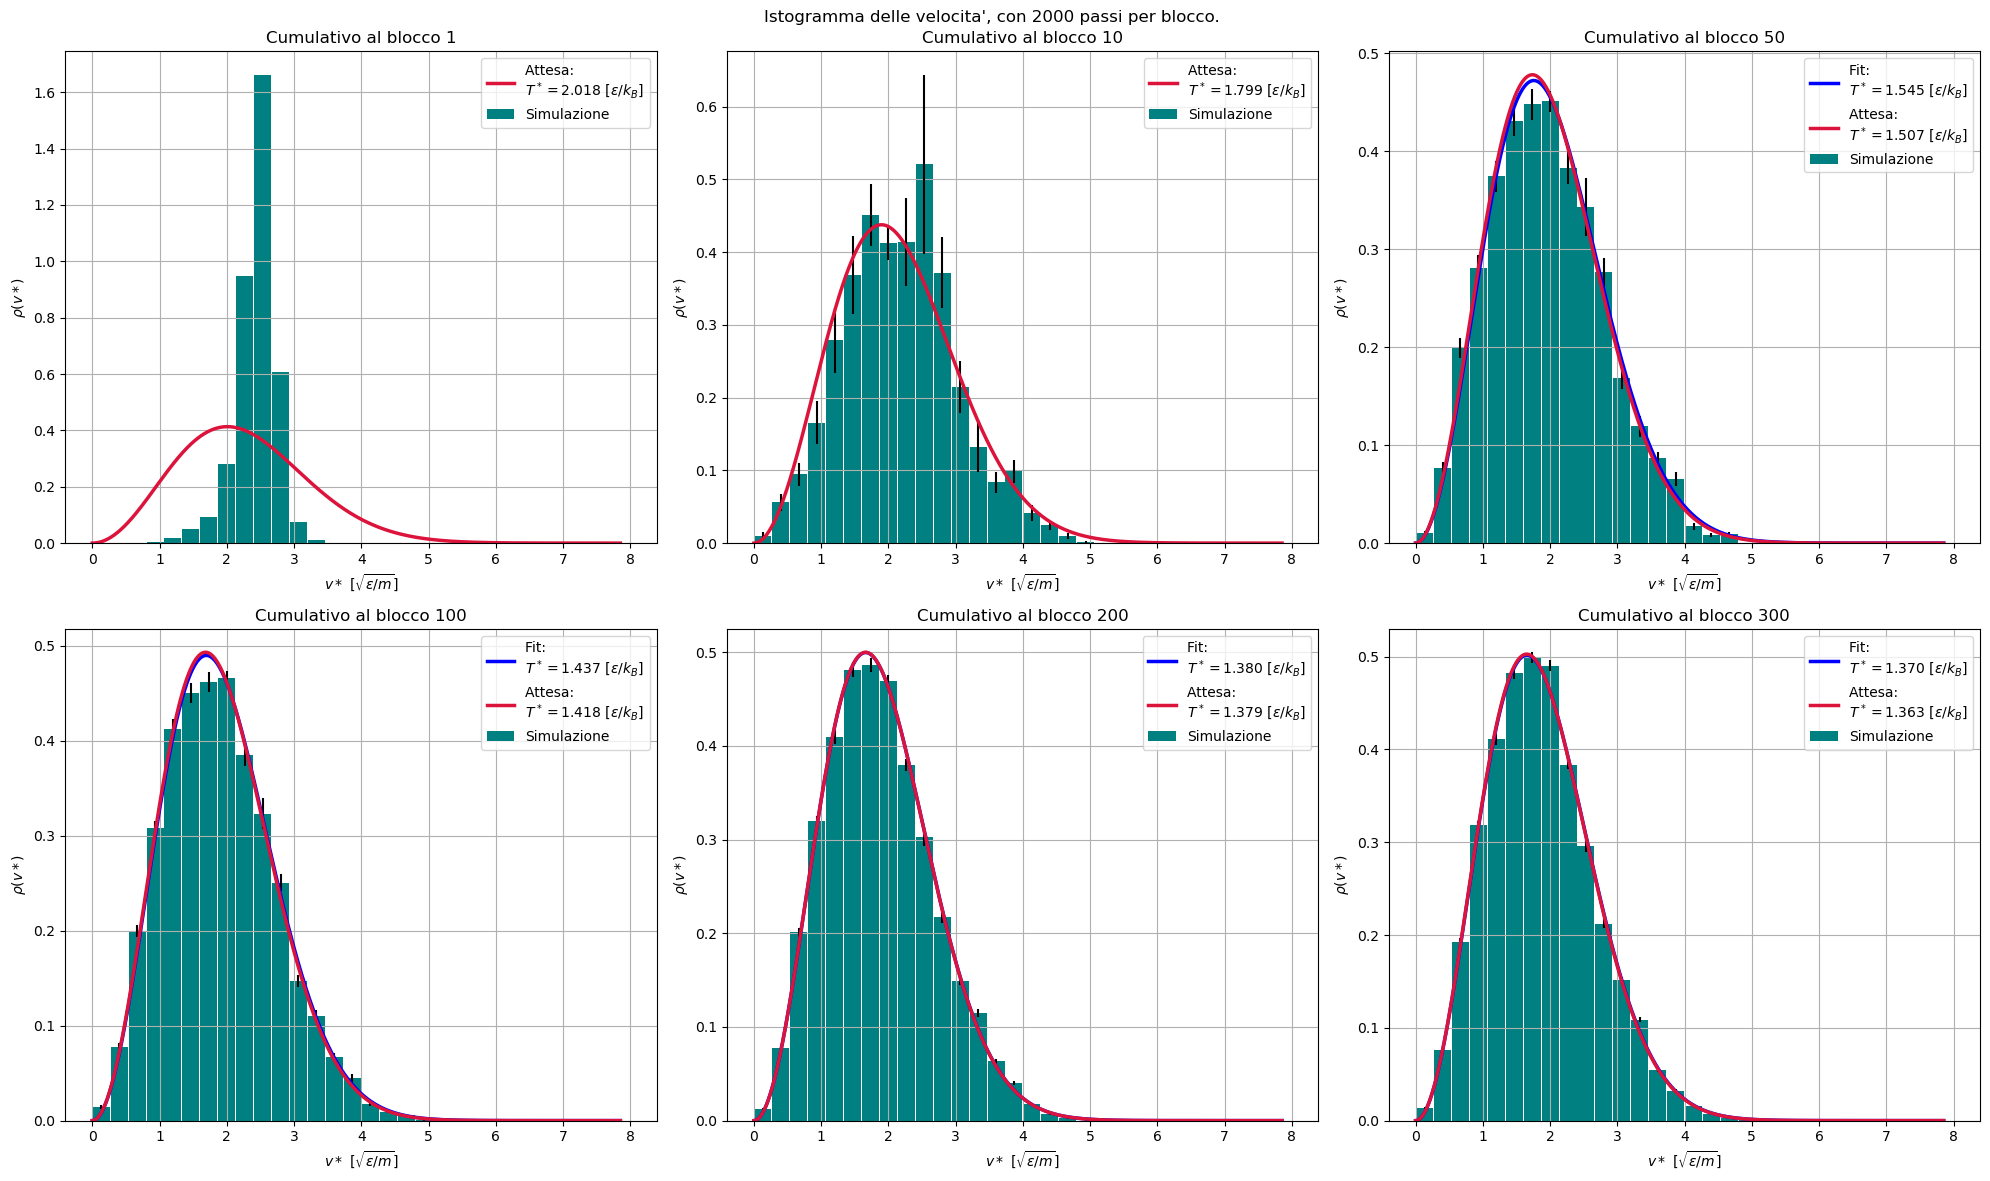

In [16]:
v=np.linspace(0,(len(bins)+1)*bin_size,1000)


fig,axs = plt.subplots(2,3,figsize=[20,12])

for i,ax in enumerate(axs.flatten()):
    #dati
    n=show_block[i] #numero del blocco
    ax.bar(bins,block_counts[n],width=bin_size,yerr=block_error[n],color="teal",label="Simulazione")
    if not (n==1 or n==10):# non ha senso confrontare col fit per un numero basso di blocchi
        ax.plot(v,p(v,T_fit[i]),color="blue", linewidth=2.5,label="Fit: " + "\n" + rf"$T^*=${T_fit[i]:.3f} $[\epsilon/k_B] $") #plotta il fit
    ax.plot(v,p(v,T_sim[i]),color="crimson", linewidth=2.5,label="Attesa: " + "\n" + rf"$ T^*=${T_sim[i]:.3f} $[\epsilon/k_B] $") #plotta la distribuzione attesa
    ax.legend(loc="upper right")
    ax.grid(True)
    ax.set_title(f"Cumulativo al blocco {n}")
    ax.set_xlabel(r"$v* \ [\sqrt{\epsilon/m}]$")
    ax.set_ylabel(r"$\rho(v*)$")


plt.suptitle(f"Istogramma delle velocita', con {M} passi per blocco. ")

plt.tight_layout()
plt.show()

E' evidente che la distribuzione delle velocità, che al blocco 1 rassomiglia una delta di Dirac, tende ad una distribuzione di Maxwell-Boltzmann. 

### <span style="color:DodgerBlue"> Esercizio 4.3 </span>


Con lo stesso sistema dell'esercizio 4.2, si esegue una simulazione con $N=50$ blocchi e $M=100$ step per blocco. Dopodichè, partendo dalla configurazione finale, si inverte la freccia del tempo e si esegue una nuova simulazione. 

Per invertire la freccia del tempo è sufficiente inizializzare la velocità delle particelle della nuova simulazione con la velocità finale a segno invertito. 

Poichè nell'algoritmo di Verlet le velocità sono date dalla formula:$$ \vec{v}(t)=\frac{\vec{r}(t+\delta t)-\vec{r}(t\delta t)}{2}$$
si nota che, operativamente, questa inversione può essere effettuata scambiando l'ultimo set di coordinate con il penultimo prima di utilizzarli come punto di partenza per la nuova simulazione in modalità restart. 


In [17]:
tempdir=pd.read_csv("l_04_es3/50_BLOCCHI/temperature_for.dat",sep="\s+")
temprev=pd.read_csv("l_04_es3/50_BLOCCHI/temperature.dat",sep="\s+")
potendir=pd.read_csv("l_04_es3/50_BLOCCHI/potential_energy_for.dat",sep="\s+")
potenrev=pd.read_csv("l_04_es3/50_BLOCCHI/potential_energy.dat",sep="\s+")
blocks=tempdir["#BLOCK:"]
T_forward=tempdir["ACTUAL_T:"]
T_backwards=temprev["ACTUAL_T:"]
pot_en_forward=potendir["ACTUAL_PE:"]
pot_en_backward=potenrev["ACTUAL_PE:"]





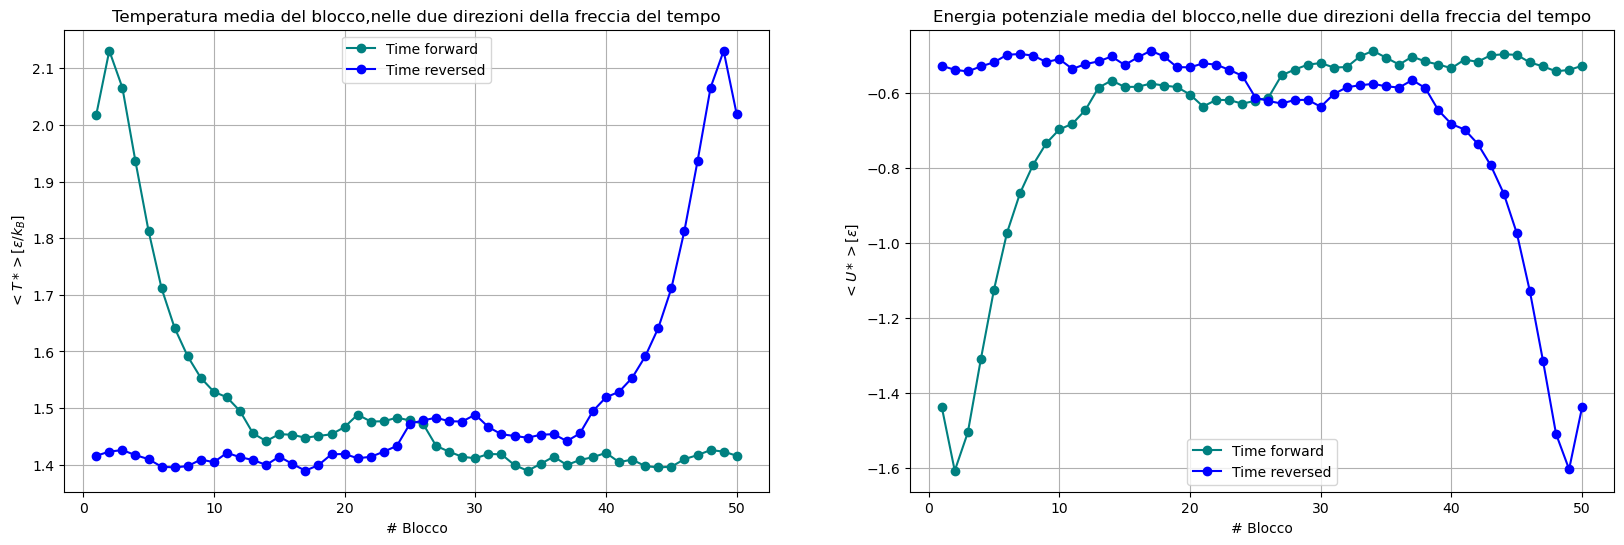

In [18]:
fig,ax =plt.subplots(1,2,figsize=[20,6])

ax[0].plot(blocks,T_forward, label="Time forward",marker="o",color="teal")
ax[0].plot(blocks,T_backwards,label="Time reversed",marker="o",color="blue")
ax[0].set_xlabel("# Blocco")
ax[0].set_ylabel(r"$<T*> [\epsilon / k_B]$")

ax[0].set_title("Temperatura media del blocco,nelle due direzioni della freccia del tempo")
ax[0].legend()
ax[0].grid()

ax[1].plot(blocks,pot_en_forward, label="Time forward",marker="o",color="teal")
ax[1].plot(blocks,pot_en_backward,label="Time reversed",marker="o",color="blue")
ax[1].set_xlabel("# Blocco")
ax[1].set_ylabel(r"$<U*> [\epsilon]$")

ax[1].set_title("Energia potenziale media del blocco,nelle due direzioni della freccia del tempo")
ax[1].legend()
ax[1].grid()




E' evidente che il sistema, durante la simulazione time reversal, ripercorre i propri passi, per ritornare nella configurazione iniziale a bassa entropia. Ciò è coerente con la simmetria per inversione temporale dell'algoritmo di Verlet. 

Si è ripetuta la simulazione con N=500 blocchi e M=100 step per blocco.

In [19]:
tempdir=pd.read_csv("l_04_es3/500_BLOCCHI/temperature_for.dat",sep="\s+")
temprev=pd.read_csv("l_04_es3/500_BLOCCHI/temperature.dat",sep="\s+")
potendir=pd.read_csv("l_04_es3/500_BLOCCHI/potential_energy_for.dat",sep="\s+")
potenrev=pd.read_csv("l_04_es3/500_BLOCCHI/potential_energy.dat",sep="\s+")
blocks=tempdir["#BLOCK:"]
T_forward=tempdir["ACTUAL_T:"]
T_backwards=temprev["ACTUAL_T:"]
pot_en_forward=potendir["ACTUAL_PE:"]
pot_en_backward=potenrev["ACTUAL_PE:"]





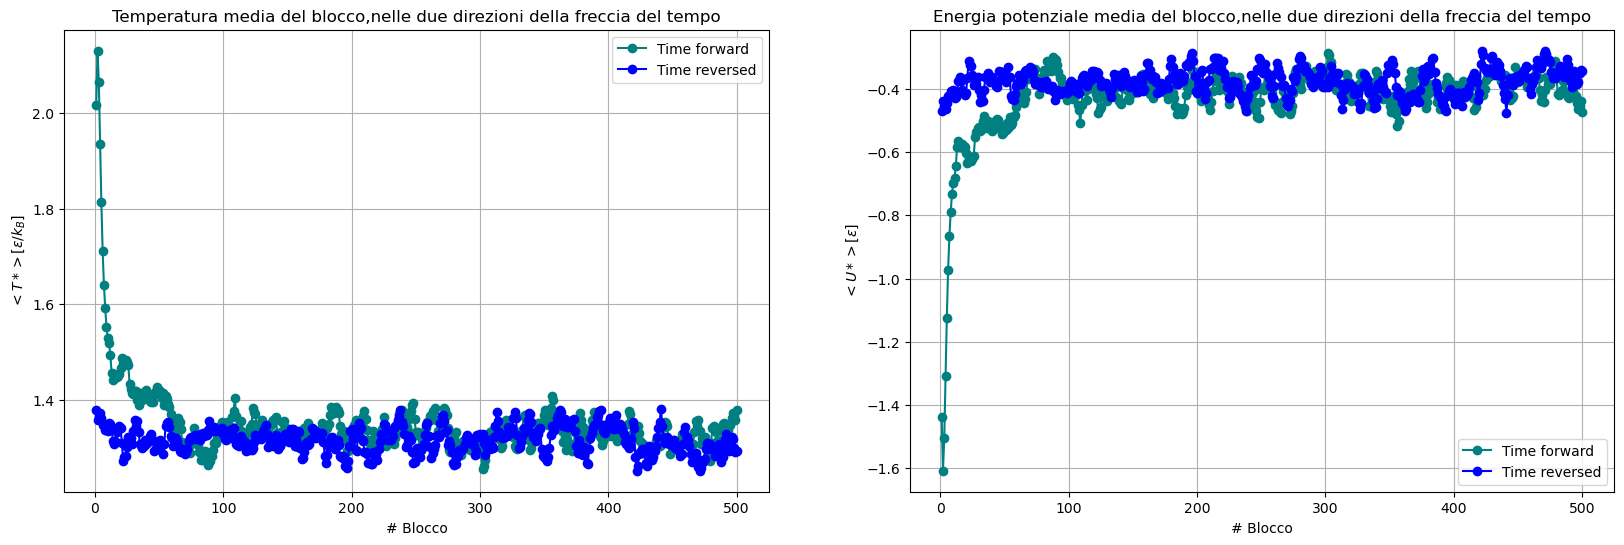

In [20]:
fig,ax =plt.subplots(1,2,figsize=[20,6])

ax[0].plot(blocks,T_forward, label="Time forward",marker="o",color="teal")
ax[0].plot(blocks,T_backwards,label="Time reversed",marker="o",color="blue")
ax[0].set_xlabel("# Blocco")
ax[0].set_ylabel(r"$<T*> [\epsilon / k_B]$")

ax[0].set_title("Temperatura media del blocco,nelle due direzioni della freccia del tempo")
ax[0].legend()
ax[0].grid()

ax[1].plot(blocks,pot_en_forward, label="Time forward",marker="o",color="teal")
ax[1].plot(blocks,pot_en_backward,label="Time reversed",marker="o",color="blue")
ax[1].set_xlabel("# Blocco")
ax[1].set_ylabel(r"$<U*> [\epsilon]$")

ax[1].set_title("Energia potenziale media del blocco,nelle due direzioni della freccia del tempo")
ax[1].legend()
ax[1].grid()


